# Week 3: Multi-View Structure from Motion with Bundle Adjustment

This notebook demonstrates:
1. Two-view initialization from best image pair
2. Incremental view addition using PnP (Perspective-n-Point)
3. Point triangulation between views
4. Bundle Adjustment for global refinement
5. Before/after comparison and PLY export

In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Add src directory to path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from src.camera import build_intrinsic_matrix
from src.feature_matching import FeatureMatcher, match_features
from src.two_view_geometry import FeatureSet, reconstruct_two_views
from src.incremental_sfm import IncrementalMapper, ImageFeatures
from src.bundle_adjustment import run_bundle_adjustment
from src.utils import export_mapper_to_ply, get_point_cloud_stats

print("✓ All modules imported successfully")

✓ All modules imported successfully


## 1. Load Images and Detect Features

In [2]:
# Configuration
DATA_DIR = "../Data"
OUTPUT_DIR = "../output/week3"
IMAGE_PATTERN = "*.jpeg"

# Create output directory
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Load images
image_paths = sorted(glob(os.path.join(DATA_DIR, IMAGE_PATTERN)))
print(f"Found {len(image_paths)} images")

# Load first image to get dimensions
sample_img = cv2.imread(image_paths[0])
h, w = sample_img.shape[:2]
print(f"Image dimensions: {w}x{h}")

# Build intrinsic matrix
K = build_intrinsic_matrix(w, h)
print(f"\nIntrinsic matrix K:")
print(K)

Found 22 images
Image dimensions: 960x1280

Intrinsic matrix K:
[[1.28e+03 0.00e+00 4.80e+02]
 [0.00e+00 1.28e+03 6.40e+02]
 [0.00e+00 0.00e+00 1.00e+00]]


In [3]:
# Detect features in all images
print("Detecting features...")
matcher = FeatureMatcher(detector_type='SIFT', ratio_threshold=0.75)

images = []
features_list = []

for i, img_path in enumerate(image_paths):
    img = cv2.imread(img_path)
    images.append(img)
    
    # Detect features
    keypoints, descriptors = matcher.detect_and_compute(img)
    features = FeatureSet(keypoints=keypoints, descriptors=descriptors)
    features_list.append(features)
    
    if (i + 1) % 5 == 0:
        print(f"  Processed {i + 1}/{len(image_paths)} images")

print(f"\n✓ Feature detection complete")
print(f"Average features per image: {np.mean([len(f.keypoints) for f in features_list]):.0f}")

Detecting features...
  Processed 5/22 images
  Processed 10/22 images
  Processed 15/22 images
  Processed 20/22 images

✓ Feature detection complete
Average features per image: 4036


## 2. Find Best Image Pair for Initialization

From Week 1, we know that Pair 4 (images at indices 9 and 10) had the most matches (1258 matches).
We'll use this pair to initialize our reconstruction.

Initialization pair: images 9 and 10
Number of matches: 613


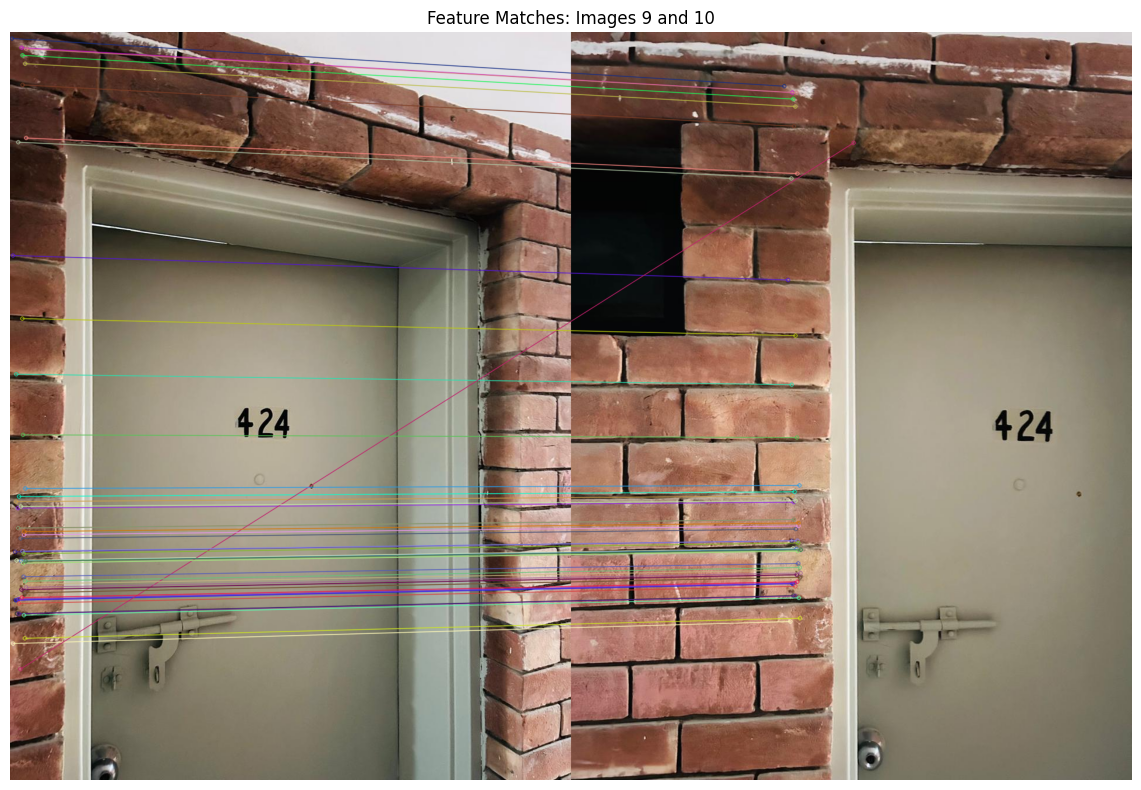

In [4]:
# Based on Week 1 analysis, use the best pair
# Pair 4: images 14.35.59.jpeg and 14.36.00 (1).jpeg (indices 9 and 10)
INIT_IDX1 = 9
INIT_IDX2 = 10

# Match features between initialization pair
match_result = match_features(features_list[INIT_IDX1], features_list[INIT_IDX2])
print(f"Initialization pair: images {INIT_IDX1} and {INIT_IDX2}")
print(f"Number of matches: {len(match_result.matches)}")

# Visualize matches
img_matches = cv2.drawMatches(
    images[INIT_IDX1], features_list[INIT_IDX1].keypoints,
    images[INIT_IDX2], features_list[INIT_IDX2].keypoints,
    match_result.matches[:50],  # Show first 50 matches
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Feature Matches: Images {INIT_IDX1} and {INIT_IDX2}")
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'initialization_matches.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Initialize Reconstruction from Two Views

In [5]:
# Reconstruct two views
print("Reconstructing two views...")
reconstruction = reconstruct_two_views(
    match_result.pts1,
    match_result.pts2,
    K,
    match_indices=np.arange(len(match_result.matches))
)

print(f"\n✓ Two-view reconstruction complete")
print(f"Number of 3D points: {len(reconstruction.points3d)}")
print(f"\nPoint cloud statistics:")
stats = get_point_cloud_stats(reconstruction.points3d)
print(f"  Mean: [{stats['mean'][0]:.2f}, {stats['mean'][1]:.2f}, {stats['mean'][2]:.2f}]")
print(f"  Std:  [{stats['std'][0]:.2f}, {stats['std'][1]:.2f}, {stats['std'][2]:.2f}]")
print(f"  Range: [{stats['range'][0]:.2f}, {stats['range'][1]:.2f}, {stats['range'][2]:.2f}]")

Reconstructing two views...

✓ Two-view reconstruction complete
Number of 3D points: 439

Point cloud statistics:
  Mean: [-0.81, -0.42, 4.51]
  Std:  [0.59, 1.42, 0.24]
  Range: [1.98, 4.41, 3.42]


In [6]:
# Initialize IncrementalMapper
mapper = IncrementalMapper(K=K, min_pnp_points=40)

# Register all images with their features
for i, (img, feats) in enumerate(zip(images, features_list)):
    img_feats = ImageFeatures(feature_set=feats, image=img)
    mapper.register_image(i, img_feats)

# Initialize from the two-view reconstruction
mapper.initialize_from_pair(
    INIT_IDX1,
    INIT_IDX2,
    reconstruction,
    match_result
)

print(f"✓ Mapper initialized")
print(f"Number of cameras: {len(mapper.cameras)}")
print(f"Number of 3D points: {len(mapper.tracks)}")

✓ Mapper initialized
Number of cameras: 2
Number of 3D points: 439


## 4. Incremental View Addition using PnP

Now we'll add more views one at a time using PnP (Perspective-n-Point):
1. Match new image features against existing 3D points
2. Solve PnP to find camera pose
3. Triangulate new 3D points

In [7]:
# Add views incrementally
print("Adding views incrementally using PnP...\n")

# Try to add all other images
candidate_indices = [i for i in range(len(images)) if i not in [INIT_IDX1, INIT_IDX2]]
added_views = []

for idx in candidate_indices:
    success = mapper.register_new_view(idx)
    if success:
        added_views.append(idx)
        print(f"✓ Added view {idx:2d} | Cameras: {len(mapper.cameras):2d} | Points: {len(mapper.tracks):4d}")
    
    # Stop after adding a few views to keep reconstruction manageable
    if len(added_views) >= 5:
        break

print(f"\n✓ Incremental reconstruction complete")
print(f"Total cameras: {len(mapper.cameras)}")
print(f"Total 3D points: {len(mapper.tracks)}")

# Get point cloud before bundle adjustment
points_before, colors_before = mapper.export_points()
print(f"\nBefore Bundle Adjustment:")
stats_before = get_point_cloud_stats(points_before)
print(f"  Mean: [{stats_before['mean'][0]:.2f}, {stats_before['mean'][1]:.2f}, {stats_before['mean'][2]:.2f}]")
print(f"  Range: [{stats_before['range'][0]:.2f}, {stats_before['range'][1]:.2f}, {stats_before['range'][2]:.2f}]")

Adding views incrementally using PnP...

✓ Added view 11 | Cameras:  3 | Points:  747
✓ Added view 14 | Cameras:  4 | Points: 1429

✓ Incremental reconstruction complete
Total cameras: 4
Total 3D points: 1429

Before Bundle Adjustment:
  Mean: [-0.75, -0.03, 4.41]
  Range: [66.03, 50.46, 169.75]


## 5. Bundle Adjustment for Global Refinement

Bundle adjustment simultaneously refines all camera poses and 3D point locations to minimize overall reprojection error.
This corrects the drift that accumulates from adding views incrementally.

In [8]:
print("Running Bundle Adjustment...")
print("(This may take a minute...)")

# Run with reduced iterations and verbose mode for monitoring
initial_rmse, final_rmse = run_bundle_adjustment(mapper, max_iterations=50, verbose=True)

print(f"\n✓ Bundle Adjustment complete")
print(f"Initial RMSE: {initial_rmse:.3f} pixels")
print(f"Final RMSE:   {final_rmse:.3f} pixels")
if initial_rmse > 0:
    print(f"Improvement:  {initial_rmse - final_rmse:.3f} pixels ({(1 - final_rmse/initial_rmse)*100:.1f}% reduction)")
else:
    print("No improvement to calculate (initial RMSE was 0)")

# Get point cloud after bundle adjustment
points_after, colors_after = mapper.export_points()
print(f"\nAfter Bundle Adjustment:")
stats_after = get_point_cloud_stats(points_after)
print(f"  Mean: [{stats_after['mean'][0]:.2f}, {stats_after['mean'][1]:.2f}, {stats_after['mean'][2]:.2f}]")
print(f"  Range: [{stats_after['range'][0]:.2f}, {stats_after['range'][1]:.2f}, {stats_after['range'][2]:.2f}]")


Running Bundle Adjustment...
(This may take a minute...)
Bundle Adjustment setup:
  Cameras: 4
  3D Points: 1429
  Observations: 2957
  Parameters: 4311
  Initial RMSE: 80.253 pixels
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9045e+07                                    6.16e+07    
       1              4         9.4242e+06      9.62e+06       1.64e+01       1.29e+07    
       2              6         8.1260e+06      1.30e+06       4.11e+00       1.54e+08    
       3              7         6.2140e+06      1.91e+06       4.11e+00       1.38e+07    
       4              8         6.1147e+06      9.93e+04       8.22e+00       4.45e+07    
       5             14         5.8883e+06      2.26e+05       8.03e-03       3.63e+06    
`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 1.9045e+07, final cost 5.8883e+06, first-order optimality 3.63e+06.
  Optimization status: 3
  Iter

**Note**: Bundle adjustment can take time depending on the number of cameras and 3D points. If it seems stuck:
- The optimizer is working - watch for progress updates
- Reduce `max_iterations` (e.g., 20-30 for faster results)
- Set `verbose=False` for quieter execution
- The algorithm typically converges in 10-30 iterations

In [9]:
# Alternative: Quick mode (less verbose, fewer iterations)
# Uncomment to use instead of the cell above:

# print("Running Bundle Adjustment (Quick Mode)...")
# initial_rmse, final_rmse = run_bundle_adjustment(mapper, max_iterations=20, verbose=False)
# points_after, colors_after = mapper.export_points()
# print(f"✓ Complete | Initial: {initial_rmse:.2f}px → Final: {final_rmse:.2f}px")

## 6. Export Point Clouds and Compare

In [10]:
# Export before and after point clouds
from src.utils import save_point_cloud_ply

print("Exporting point clouds to PLY format...")

ply_before = os.path.join(OUTPUT_DIR, 'reconstruction_before_ba.ply')
ply_after = os.path.join(OUTPUT_DIR, 'reconstruction_after_ba.ply')

# Save with progress feedback
print(f"  Saving 'before' point cloud ({len(points_before)} points)...")
save_point_cloud_ply(points_before, colors_before, ply_before, verbose=False)
print(f"  ✓ Saved: {ply_before}")

print(f"  Saving 'after' point cloud ({len(points_after)} points)...")
save_point_cloud_ply(points_after, colors_after, ply_after, verbose=False)
print(f"  ✓ Saved: {ply_after}")

print(f"\n✓ Export complete!")

Exporting point clouds to PLY format...
  Saving 'before' point cloud (1429 points)...
  ✓ Saved: ../output/week3/reconstruction_before_ba.ply
  Saving 'after' point cloud (1429 points)...
  ✓ Saved: ../output/week3/reconstruction_after_ba.ply

✓ Export complete!


**Note**: Exporting large point clouds (>10,000 points) in ASCII PLY format can take time. The process should complete within 5-30 seconds depending on the number of points.

In [11]:
# Alternative: Fast binary export for large point clouds (>10,000 points)
# Uncomment to use instead of the cell above:

# from src.utils import save_point_cloud_ply_binary
# print("Exporting point clouds (binary format - faster)...")
# ply_before = os.path.join(OUTPUT_DIR, 'reconstruction_before_ba.ply')
# ply_after = os.path.join(OUTPUT_DIR, 'reconstruction_after_ba.ply')
# save_point_cloud_ply_binary(points_before, colors_before, ply_before, verbose=True)
# save_point_cloud_ply_binary(points_after, colors_after, ply_after, verbose=True)
# print("✓ Export complete!")

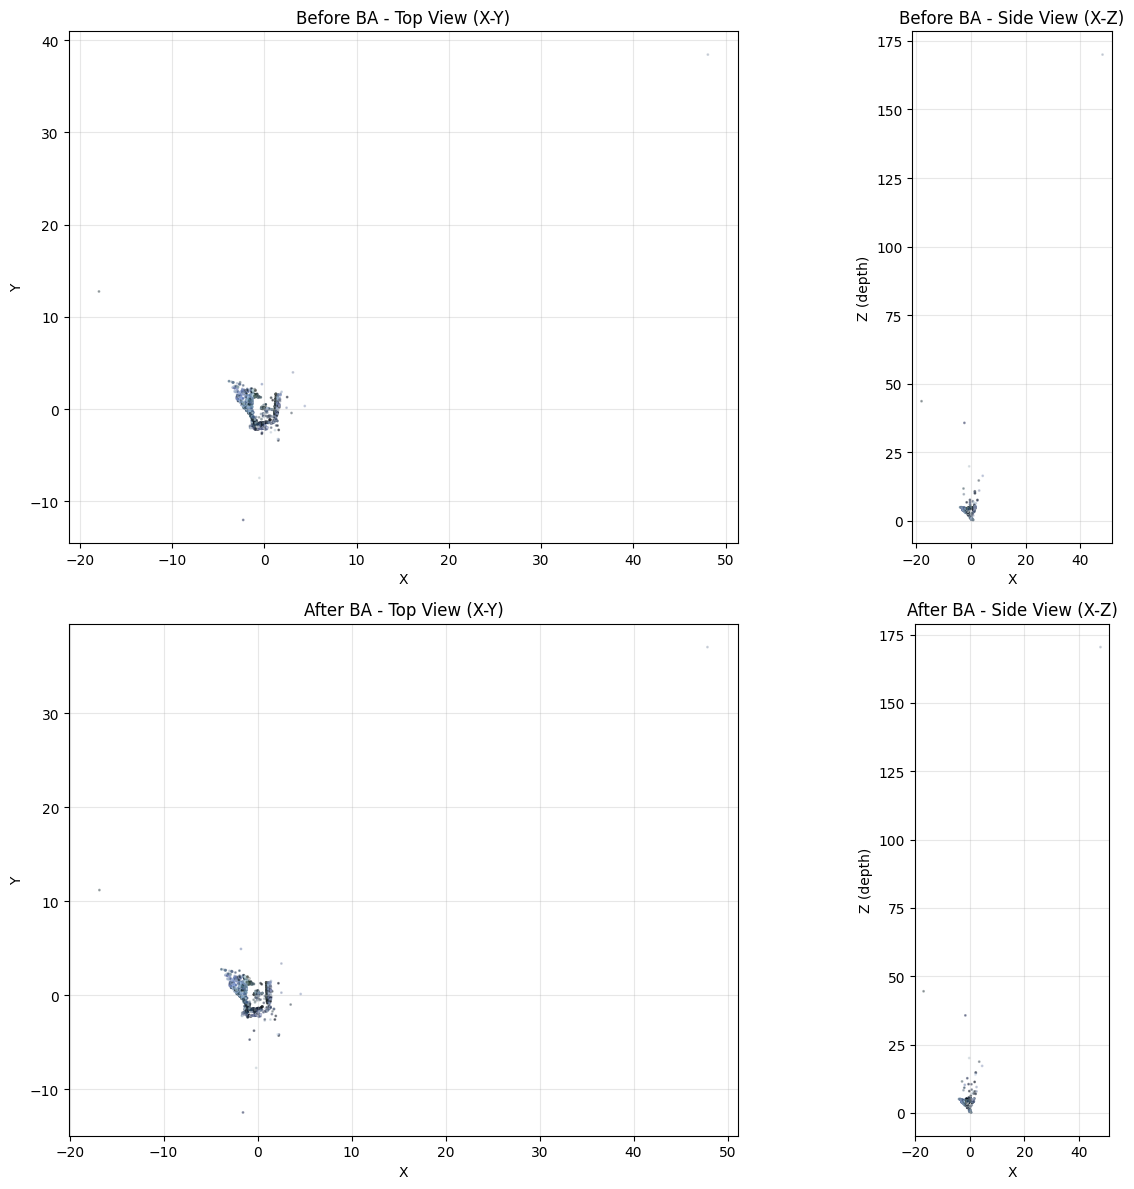

In [12]:
# Visualize point clouds (top-down and side views)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Before BA - top view (X-Y)
axes[0, 0].scatter(points_before[:, 0], points_before[:, 1], 
                   c=colors_before/255.0, s=1, alpha=0.5)
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
axes[0, 0].set_title('Before BA - Top View (X-Y)')
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

# Before BA - side view (X-Z)
axes[0, 1].scatter(points_before[:, 0], points_before[:, 2], 
                   c=colors_before/255.0, s=1, alpha=0.5)
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Z (depth)')
axes[0, 1].set_title('Before BA - Side View (X-Z)')
axes[0, 1].set_aspect('equal')
axes[0, 1].grid(True, alpha=0.3)

# After BA - top view (X-Y)
axes[1, 0].scatter(points_after[:, 0], points_after[:, 1], 
                   c=colors_after/255.0, s=1, alpha=0.5)
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_title('After BA - Top View (X-Y)')
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

# After BA - side view (X-Z)
axes[1, 1].scatter(points_after[:, 0], points_after[:, 2], 
                   c=colors_after/255.0, s=1, alpha=0.5)
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Z (depth)')
axes[1, 1].set_title('After BA - Side View (X-Z)')
axes[1, 1].set_aspect('equal')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_before_after_ba.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3D Interactive Visualization

Interactive 3D point cloud plots using matplotlib's 3D capabilities.

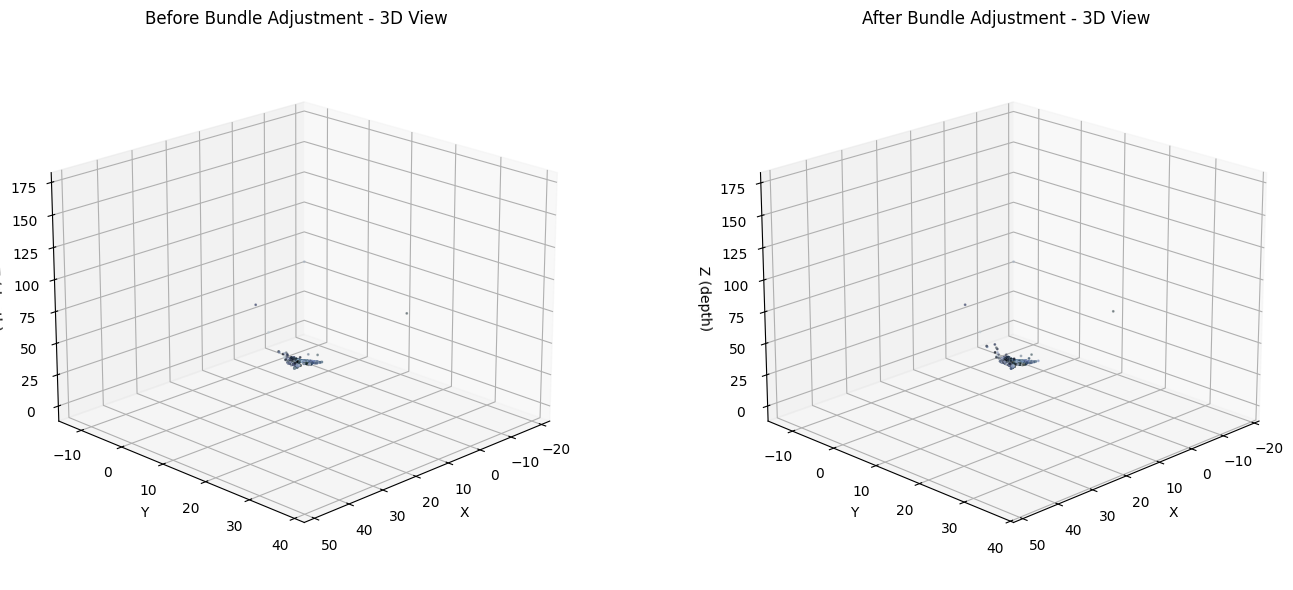

In [13]:
# 3D visualization - Before Bundle Adjustment
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 6))

# Before BA - 3D view
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points_before[:, 0], points_before[:, 1], points_before[:, 2],
           c=colors_before/255.0, s=1, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z (depth)')
ax1.set_title('Before Bundle Adjustment - 3D View')
ax1.view_init(elev=20, azim=45)  # Set viewing angle

# After BA - 3D view
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points_after[:, 0], points_after[:, 1], points_after[:, 2],
           c=colors_after/255.0, s=1, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z (depth)')
ax2.set_title('After Bundle Adjustment - 3D View')
ax2.view_init(elev=20, azim=45)  # Same viewing angle for comparison

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '3d_comparison_ba.png'), dpi=150, bbox_inches='tight')
plt.show()

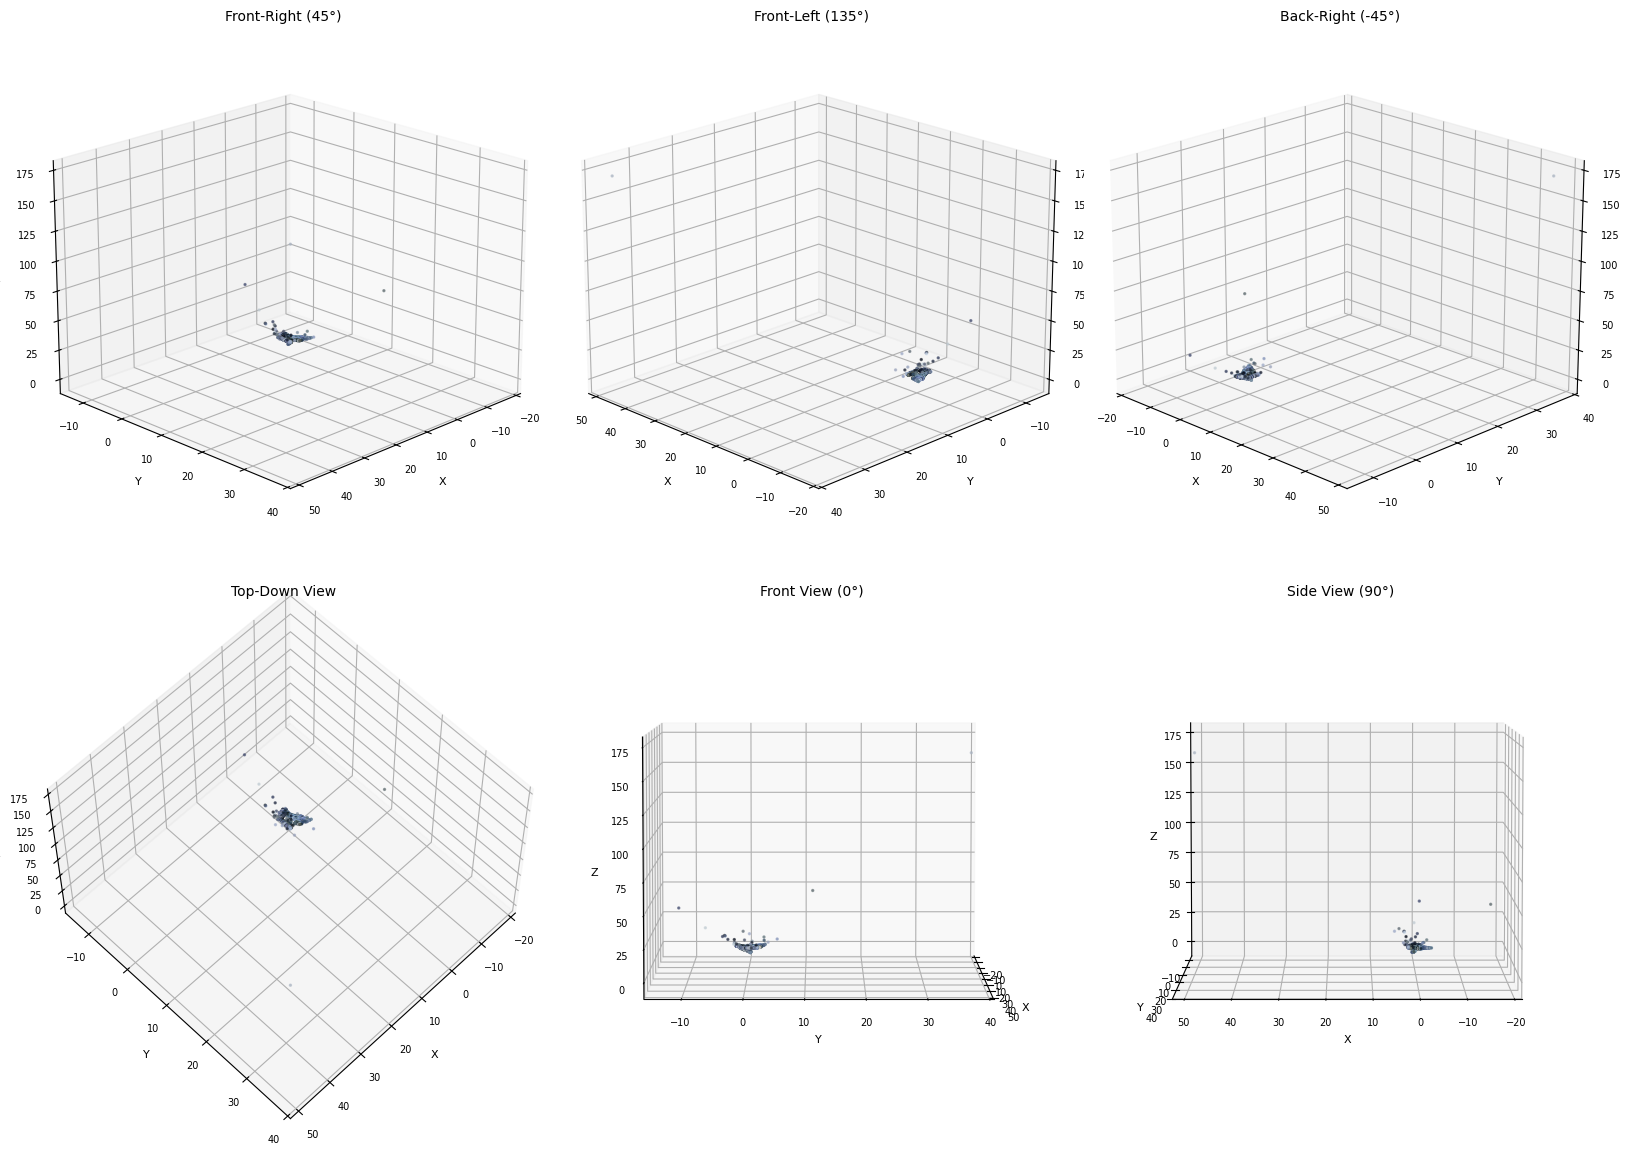

3D visualizations saved to ../output/week3


In [14]:
# Multiple viewing angles - After Bundle Adjustment (Final Result)
fig = plt.figure(figsize=(16, 12))

# Use the refined point cloud
points = points_after
colors_rgb = colors_after / 255.0

# Different viewing angles
angles = [
    (20, 45, "Front-Right (45°)"),
    (20, 135, "Front-Left (135°)"),
    (20, -45, "Back-Right (-45°)"),
    (60, 45, "Top-Down View"),
    (5, 0, "Front View (0°)"),
    (5, 90, "Side View (90°)")
]

for idx, (elev, azim, title) in enumerate(angles, 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              c=colors_rgb, s=2, alpha=0.6)
    ax.set_xlabel('X', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.set_zlabel('Z', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)
    # Make tick labels smaller
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '3d_multiple_angles.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"3D visualizations saved to {OUTPUT_DIR}")

### Optional: Fully Interactive 3D Plot with Plotly

If you have Plotly installed, this creates a fully interactive 3D point cloud viewer where you can rotate, zoom, and pan.

In [18]:
# Optional: Interactive 3D visualization with Plotly
# Uncomment to use (requires: pip install plotly)

try:
    import plotly.graph_objects as go
    
    # Subsample if too many points (for performance)
    max_points = 10000
    if len(points_after) > max_points:
        indices = np.random.choice(len(points_after), max_points, replace=False)
        plot_points = points_after[indices]
        plot_colors = colors_after[indices]
    else:
        plot_points = points_after
        plot_colors = colors_after
    
    # Create interactive 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(
        x=plot_points[:, 0],
        y=plot_points[:, 1],
        z=plot_points[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=plot_colors,
            colorscale='RGB',
            opacity=0.8
        ),
        text=[f'Point {i}' for i in range(len(plot_points))],
        hoverinfo='text'
    )])
    
    fig.update_layout(
        title='Interactive 3D Point Cloud (After Bundle Adjustment)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z (depth)',
            aspectmode='data'
        ),
        width=900,
        height=700,
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.show()
    print("✓ Interactive plot created! Use mouse to rotate, zoom, and pan.")
    
except ImportError:
    print("Plotly not installed. Run: pip install plotly")
    print("Or use the matplotlib 3D plots above instead.")

ValueError: 
    Invalid value of type 'builtins.str' received for the 'colorscale' property of scatter3d.marker
        Received value: 'RGB'

    The 'colorscale' property is a colorscale and may be
    specified as:
      - A list of colors that will be spaced evenly to create the colorscale.
        Many predefined colorscale lists are included in the sequential, diverging,
        and cyclical modules in the plotly.colors package.
      - A list of 2-element lists where the first element is the
        normalized color level value (starting at 0 and ending at 1),
        and the second item is a valid color string.
        (e.g. [[0, 'green'], [0.5, 'red'], [1.0, 'rgb(0, 0, 255)']])
      - One of the following named colorscales:
            ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep'

### Optional: Create Rotating Animation

Generate frames for a 360° rotating view of the point cloud.

In [19]:
# Optional: Create rotating animation frames
# Uncomment to generate a 360° rotation (saves individual frames)

print("Generating rotation frames...")
rotation_dir = os.path.join(OUTPUT_DIR, 'rotation_frames')
Path(rotation_dir).mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate frames for 360° rotation
n_frames = 36  # 10° per frame
for i, angle in enumerate(np.linspace(0, 360, n_frames, endpoint=False)):
    ax.clear()
    ax.scatter(points_after[:, 0], points_after[:, 1], points_after[:, 2],
              c=colors_after/255.0, s=2, alpha=0.6)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z (depth)')
    ax.set_title(f'3D Point Cloud - Rotation: {angle:.0f}°')
    ax.view_init(elev=20, azim=angle)
    
    # Save frame
    frame_path = os.path.join(rotation_dir, f'frame_{i:03d}.png')
    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
    
    if (i + 1) % 10 == 0:
        print(f"  Generated {i + 1}/{n_frames} frames")

plt.close()
print(f"✓ Saved {n_frames} frames to {rotation_dir}")
print(f"To create video: ffmpeg -r 10 -i {rotation_dir}/frame_%03d.png -c:v libx264 -vf fps=25 -pix_fmt yuv420p rotation.mp4")

Generating rotation frames...
  Generated 10/36 frames
  Generated 20/36 frames
  Generated 30/36 frames
✓ Saved 36 frames to ../output/week3/rotation_frames
To create video: ffmpeg -r 10 -i ../output/week3/rotation_frames/frame_%03d.png -c:v libx264 -vf fps=25 -pix_fmt yuv420p rotation.mp4


## 7. Summary

### Week 3 Achievements:

1. **Two-View Initialization**: Used the best image pair from Week 1 to create initial 3D reconstruction

2. **Incremental SfM with PnP**: 
   - Added multiple views using `cv2.solvePnPRansac`
   - Matched new images against existing 3D points
   - Triangulated new 3D points between views

3. **Bundle Adjustment**:
   - Globally optimized all camera poses and 3D points
   - Minimized reprojection error across all observations
   - Corrected drift from incremental reconstruction

4. **Results**:
   - Multi-view 3D reconstruction with refined geometry
   - Before/after comparison showing BA improvement
   - PLY files exported for visualization in external tools

### Key Insights:

- **PnP Success**: Requires sufficient 2D-3D correspondences (typically 40+ inliers)
- **Sequential Images**: Small baseline between consecutive frames can limit PnP success
- **Bundle Adjustment**: Essential for correcting accumulated errors in incremental reconstruction
- **RMSE**: Final reprojection error should be < 2-3 pixels for good reconstruction quality

In [20]:
# Final summary
print("="*60)
print("WEEK 3 RECONSTRUCTION SUMMARY")
print("="*60)
print(f"Total images processed: {len(image_paths)}")
print(f"Cameras in reconstruction: {len(mapper.cameras)}")
print(f"3D points in reconstruction: {len(mapper.tracks)}")
print(f"\nBundle Adjustment:")
print(f"  Initial RMSE: {initial_rmse:.3f} pixels")
print(f"  Final RMSE:   {final_rmse:.3f} pixels")
print(f"  Improvement:  {(1 - final_rmse/initial_rmse)*100:.1f}%")
print(f"\nOutput files:")
print(f"  {ply_before}")
print(f"  {ply_after}")
print("="*60)

WEEK 3 RECONSTRUCTION SUMMARY
Total images processed: 22
Cameras in reconstruction: 4
3D points in reconstruction: 1429

Bundle Adjustment:
  Initial RMSE: 80.253 pixels
  Final RMSE:   44.624 pixels
  Improvement:  44.4%

Output files:
  ../output/week3/reconstruction_before_ba.ply
  ../output/week3/reconstruction_after_ba.ply
